In [11]:
import pandas as pd
# load the dataset
df = pd.read_csv("../Dataset/phishing.csv")

In [13]:
# understand the data
df.shape

(10000, 5)

In [14]:
# check columns
df.columns

Index(['text', 'label', 'phishing_type', 'severity', 'confidence'], dtype='object')

In [15]:
# check datatype
df.info

<bound method DataFrame.info of                                                    text  label  \
0     Subject: Office maintenance\n\nThanks for your...      0   
1     Hello, your profile has been locked. Use the s...      1   
2     Hi there, congratulations! You are the winner ...      1   
3     Attention, this is the fraud prevention accoun...      1   
4     Notice, your profile has been restricted. Use ...      1   
...                                                 ...    ...   
9995  Subject: Code review summary\n\nI booked the l...      0   
9996  Hello, we talked about meeting again after the...      1   
9997  Hi there, we talked about meeting again after ...      1   
9998  Dear user, this is an expires midnight notice ...      1   
9999  Subject: Conference registration\n\nThanks for...      0   

              phishing_type severity  confidence  
0                legitimate      low        0.95  
1     credential_harvesting     high        0.89  
2            financial

In [16]:
# statical summary
df.describe()

,label,confidence
count,10000.000000,10000.000000
mean,0.600000,0.898855
std,0.489922,0.083430
min,0.000000,0.650000
25%,0.000000,0.840000
50%,1.000000,0.920000
75%,1.000000,0.970000
max,1.000000,1.000000


In [19]:
# check for null values
df.isnull().sum()
# remove null if exist
# df.dropna(inplace=True)

text             0
label            0
phishing_type    0
severity         0
confidence       0
dtype: int64

In [26]:
# check for duplicates
df.duplicated().sum()
# remove duplicates if exist
df.drop_duplicates(inplace=True)

In [28]:
# after removing duplicate check row will be reduced
# earlier there was 10000 rows but after removing duplicates it will be reduced to 9998 
df.shape

(9998, 5)

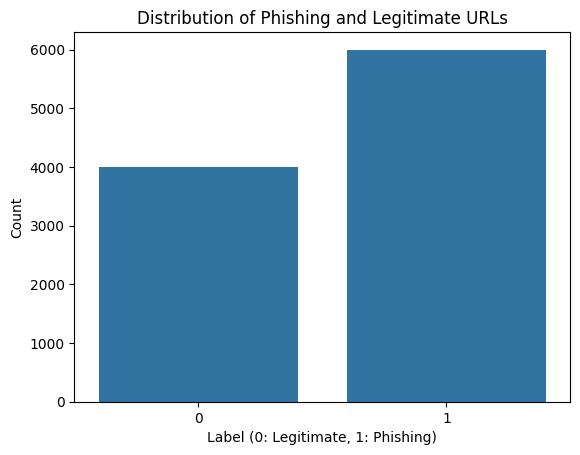

In [34]:
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='label', data=df)
plt.title('Distribution of Phishing and Legitimate URLs')
plt.xlabel('Label (0: Legitimate, 1: Phishing)')
plt.ylabel('Count')
plt.show()

Text Cleaning -

Computers cannot understand raw text like:

"URGENT!!! Click here now!!!"

We convert it into clean format.

In [30]:
# Install and import NLTK Data
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [35]:
# clean text function
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    
    # convert to lowercase
    text = text.lower()
    
    # remove special characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    # split into words
    words = text.split()
    
    # remove stopwords
    words = [word for word in words if word not in stop_words]
    
    # join words again
    return " ".join(words)

What You Will See
Before :
"URGENT!!! Click here now!!!" ,
After :
urgent click

Why This Is Important

This step :
removes noise ,
improves ML accuracy ,
makes model smarter.

In [36]:
# Apply the cleaning function to the 'url' column
df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text']].head()

,text,clean_text
0,Subject: Office maintenance\n\nThanks for your...,subject office maintenance thanks help analysi...
1,"Hello, your profile has been locked. Use the s...",hello profile locked use secure link verify us...
2,"Hi there, congratulations! You are the winner ...",hi congratulations winner refund collect gift ...
3,"Attention, this is the fraud prevention accoun...",attention fraud prevention accounts team secur...
4,"Notice, your profile has been restricted. Use ...",notice profile restricted use secure link rese...


👆 This means:

✔ Lowercase applied 

✔ Special characters removed 

✔ Stopwords removed 

✔ Text cleaned 

This step is called :   
Text Preprocessing

In [ ]:
#Convert text into numerical features using TF-IDF Vectorizer 